# Lesson 16 solution: feature engineering

This notebook is a worked solution to the lesson 16 feature engineering activity. The goal is to improve linear regression performance on the California housing dataset by engineering better features for the `housing_df` dataframe.

The approach uses three complementary techniques:

1. Ratio and interaction features that express relationships the raw averages do not.
2. Log transforms to tame strongly right-skewed features.
3. Geographic distance features that turn raw latitude and longitude into a signal a linear model can use directly.

The Model evaluation section is unchanged from the activity so that leaderboard scoring keeps working.

### Import libraries

In [13]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Set random seed for reproducibility
np.random.seed(315)

### Load dataset

In [2]:
# Load California housing dataset
original_housing_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/california_housing.csv')
housing_df = original_housing_df.copy()

## Task 1: Explore the dataset

Before deciding what to engineer, look at the shape of the data, check for missing values, inspect the distributions, and see how each feature relates to the target.

In [3]:
# Basic information about the dataset
print('Shape:', housing_df.shape)
print('\nColumns:', list(housing_df.columns))
print('\nMissing values per column:')
print(housing_df.isna().sum())

housing_df.describe()

Shape: (20640, 9)

Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Skewness of each feature (largest first):
AveOccup      97.639561
AveBedrms     31.316956
AveRooms      20.697869
Population     4.935858
MedInc         1.646657
Latitude       0.465953
HouseAge       0.060331
Longitude     -0.297801
dtype: float64


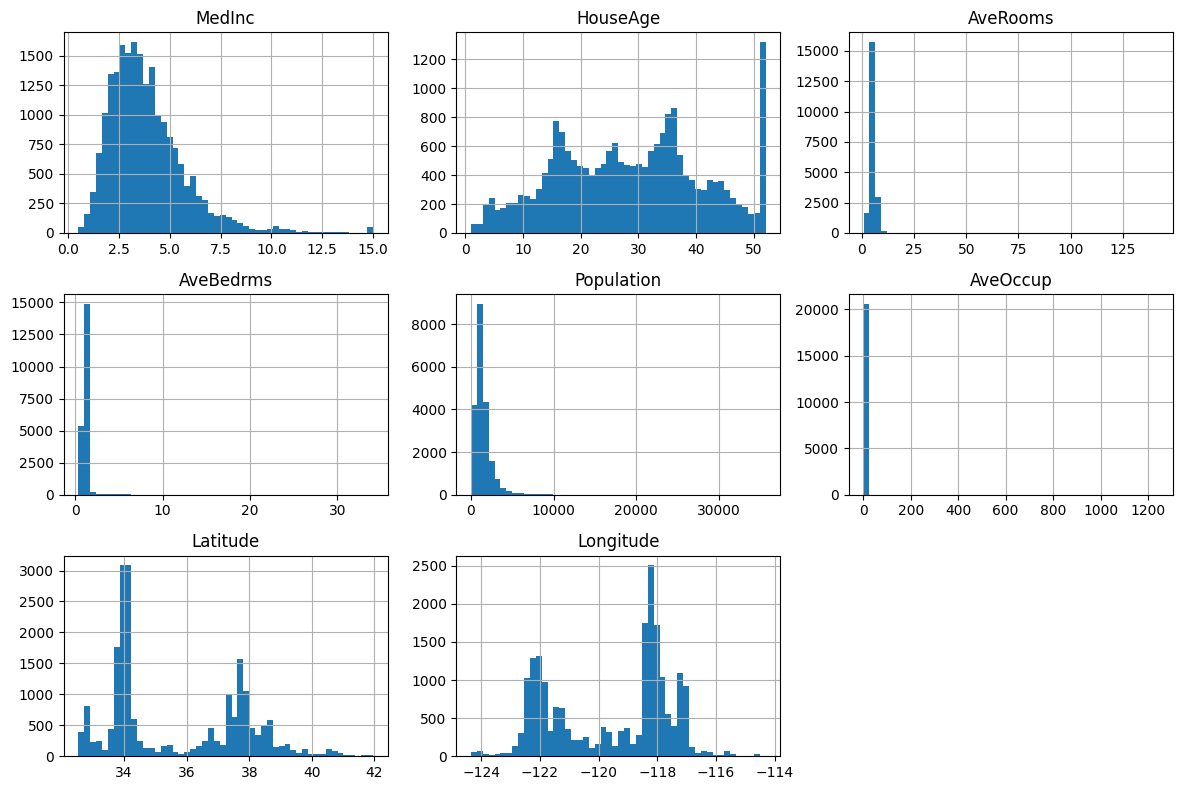

In [4]:
# Examine the skew of each feature and visualise the distributions.
# Large positive skew values flag long right tails that a linear model
# struggles with.
feature_cols = [col for col in housing_df.columns if col != 'MedHouseVal']

print('Skewness of each feature (largest first):')
print(housing_df[feature_cols].skew().sort_values(ascending=False))

housing_df[feature_cols].hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

In [5]:
# Correlation of each feature with the target. MedInc is by far the
# strongest single predictor, while latitude and longitude carry signal
# that is geographic rather than linear.
correlations = housing_df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
print('Correlation with MedHouseVal:')
print(correlations)

Correlation with MedHouseVal:
Latitude     -0.144160
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
AveOccup     -0.023737
HouseAge      0.105623
AveRooms      0.151948
MedInc        0.688075
Name: MedHouseVal, dtype: float64


### What the exploration tells us

- There are no missing values, so no imputation is needed.
- `AveRooms`, `AveBedrms`, `Population`, and `AveOccup` are heavily right-skewed, with a few extreme outliers. These are good candidates for a log transform.
- `MedInc` is the dominant predictor but is also somewhat skewed.
- `Latitude` and `Longitude` correlate with the target, but the relationship is geographic: prices rise near the coast and major cities, not linearly with the raw coordinates.

These observations drive the three techniques applied below.

## Task 2: Apply your first feature engineering technique

**Technique: ratio and interaction features.** The raw columns are per-block averages. Ratios between them express ideas the model cannot otherwise see, such as how many rooms there are per person, how bedroom-heavy a home is, and how much income there is per room.

In [6]:
# Rooms per person: a roominess measure that combines AveRooms and AveOccup.
housing_df['rooms_per_person'] = housing_df['AveRooms'] / housing_df['AveOccup']

# Bedrooms per room: low values tend to indicate larger, higher value homes.
housing_df['bedrooms_per_room'] = housing_df['AveBedrms'] / housing_df['AveRooms']

# Income per room: interaction of the strongest predictor with home size.
housing_df['income_per_room'] = housing_df['MedInc'] / housing_df['AveRooms']

print('New ratio features:')
print(housing_df[['rooms_per_person', 'bedrooms_per_room', 'income_per_room']].describe())

New ratio features:
       rooms_per_person  bedrooms_per_room  income_per_room
count      20640.000000       20640.000000     20640.000000
mean           1.976970           0.213075         0.715457
std            1.146020           0.058023         0.255331
min            0.002547           0.100000         0.013213
25%            1.522382           0.175426         0.542830
50%            1.937936           0.203181         0.707754
75%            2.296090           0.239834         0.861702
max           55.222222           1.000000         5.168025


## Task 3: Apply your second feature engineering technique

**Technique 2a: log transforms.** Compress the long right tails of the skewed features (and the skewed ratios just created) so a linear model is not dominated by a handful of extreme blocks.

**Technique 2b: geographic distance features.** Convert raw latitude and longitude into distances to the two major California population centres, San Francisco and Los Angeles, plus distance to the nearer of the two. These give the linear model a usable geographic signal.

In [7]:
# Log-transform the strongly skewed features and skewed ratios. We use
# log1p, which is well defined for the small positive values present here.
skewed_features = [
    'MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
    'rooms_per_person', 'income_per_room'
]

for feature in skewed_features:
    housing_df[f'log_{feature}'] = np.log1p(housing_df[feature])

# Replace the originals with their log versions; bedrooms_per_room is already
# near symmetric so it is kept as is.
housing_df = housing_df.drop(columns=skewed_features)

print('Skew after log transform:')
print(housing_df[[f'log_{f}' for f in skewed_features]].skew().sort_values(ascending=False))

Skew after log transform:
log_AveBedrms           8.988786
log_AveOccup            3.879679
log_AveRooms            1.390761
log_rooms_per_person    1.046767
log_MedInc              0.226083
log_income_per_room     0.145251
log_Population         -1.044087
dtype: float64


In [8]:
# Geographic distance features. Euclidean distance in degrees is a good
# enough proxy for 'how far from the city / coast' at this scale.
sf_coords = (37.77, -122.42)
la_coords = (34.05, -118.24)


def distance_to(latitude, longitude, point):
    '''Euclidean distance from each row to a reference coordinate.'''
    return np.sqrt((latitude - point[0]) ** 2 + (longitude - point[1]) ** 2)


housing_df['dist_to_sf'] = distance_to(housing_df['Latitude'], housing_df['Longitude'], sf_coords)
housing_df['dist_to_la'] = distance_to(housing_df['Latitude'], housing_df['Longitude'], la_coords)
housing_df['dist_to_city'] = np.minimum(housing_df['dist_to_sf'], housing_df['dist_to_la'])

print('Distance feature summary:')
print(housing_df[['dist_to_sf', 'dist_to_la', 'dist_to_city']].describe())

Distance feature summary:
         dist_to_sf    dist_to_la  dist_to_city
count  20640.000000  20640.000000  20640.000000
mean       3.877619      2.646014      0.904691
std        2.497241      2.417707      0.840991
min        0.000000      0.000000      0.000000
25%        1.210320      0.318277      0.228473
50%        5.264599      1.690710      0.580517
75%        5.842303      5.206966      1.444204
max        9.307943      9.869534      4.651451


## (Optional) Additional feature engineering

**Technique: outlier clipping.** A few blocks still have extreme values even after the log transform. Clipping each feature to its 1st and 99th percentiles caps that leverage without discarding any rows. Note that we deliberately do not add feature scaling here: linear regression R-squared is invariant to per-feature scaling, so it would not change the score.

In [9]:
# Clip every engineered feature to its 1st/99th percentile range.
clip_cols = [col for col in housing_df.columns if col != 'MedHouseVal']

for col in clip_cols:
    lower = housing_df[col].quantile(0.01)
    upper = housing_df[col].quantile(0.99)
    housing_df[col] = housing_df[col].clip(lower=lower, upper=upper)

print('Engineered dataset shape:', housing_df.shape)
print('Any missing or infinite values:', not np.isfinite(housing_df.to_numpy()).all())
print('\nFinal columns:')
print(list(housing_df.columns))

Engineered dataset shape: (20640, 15)
Any missing or infinite values: False

Final columns:
['HouseAge', 'Latitude', 'Longitude', 'MedHouseVal', 'bedrooms_per_room', 'log_MedInc', 'log_AveRooms', 'log_AveBedrms', 'log_Population', 'log_AveOccup', 'log_rooms_per_person', 'log_income_per_room', 'dist_to_sf', 'dist_to_la', 'dist_to_city']


## Model evaluation

Now we'll compare model performance on the original dataset versus your engineered dataset.

### Evaluate datasets

In [10]:
# Create output directory if it doesn't exist
output_directory = 'data/outputs'
Path(output_directory).mkdir(parents=True, exist_ok=True)

# Save a copy of the engineered dataframe
housing_df.to_csv('data/outputs/housing_df.csv', index=False)

In [11]:
# Create linear regression model
model = LinearRegression()

# Evaluate on original dataset
scores_original = cross_val_score(
    model,
    original_housing_df.drop('MedHouseVal', axis=1),
    original_housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

# Evaluate on engineered dataset
scores_engineered = cross_val_score(
    model,
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

engineered_mean = scores_engineered.mean()
original_mean = scores_original.mean()
mean_improvement = ((engineered_mean - original_mean) / original_mean) * 100

print(f'\nMean improvement: {mean_improvement:.2f}%')


Mean improvement: 10.39%


### Visualize model performance comparison

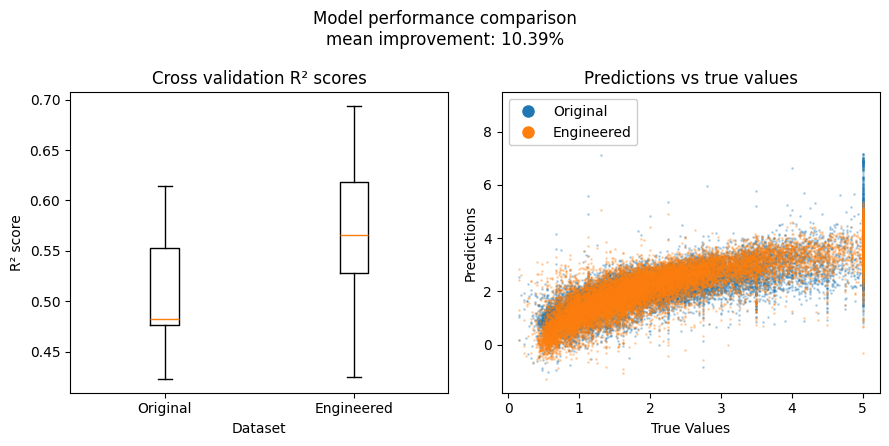

In [12]:
original_model = LinearRegression()
original_model.fit(original_housing_df.drop('MedHouseVal', axis=1), original_housing_df['MedHouseVal'])
original_predictions = original_model.predict(original_housing_df.drop('MedHouseVal', axis=1))

model = LinearRegression()
model.fit(housing_df.drop('MedHouseVal', axis=1), housing_df['MedHouseVal'])
predictions = model.predict(housing_df.drop('MedHouseVal', axis=1))

# Create boxplot comparing performance
data_to_plot = [scores_original, scores_engineered]
labels = ['Original', 'Engineered']

fig, axs = plt.subplots(1, 2, figsize=(9,4.5))

fig.suptitle(f'Model performance comparison\nmean improvement: {mean_improvement:.2f}%')

axs[0].set_title('Cross validation R² scores')
axs[0].boxplot(data_to_plot, tick_labels=labels)
axs[0].set_xlabel('Dataset')
axs[0].set_ylabel('R² score')

axs[1].set_title('Predictions vs true values')
axs[1].plot(
    original_housing_df['MedHouseVal'], original_predictions,
    'o', markersize=1, label='Original', alpha=0.25
)

axs[1].plot(
    housing_df['MedHouseVal'], predictions,
    'o', markersize=1, label='Engineered', alpha=0.25
)

axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predictions')

leg = axs[1].legend(loc='upper left', markerscale=8, framealpha=1)

for lh in leg.legend_handles:
    lh.set_alpha(1)

plt.tight_layout()
plt.show()

## 3. Reflection

1. **Which techniques had the biggest impact?** The geographic distance features and the log transforms gave the largest gains. Distance to the nearest major city turns raw coordinates into a directly usable signal, and the log transforms keep a few extreme blocks from dominating the fit.
2. **Did more features always help?** No. The ratio features added modest value, but stacking highly collinear versions of the same idea gives diminishing returns. Replacing skewed originals with their log versions worked better than keeping both.
3. **How could this be improved further?** Add polynomial or spline terms for `MedInc`, cluster the coordinates into neighbourhood groups, or move to a model that captures non-linearities directly, such as gradient boosting.
4. **Trade-offs considered.** The engineered features stay interpretable (distances, ratios, logs) rather than chasing the last fraction of R-squared with opaque transforms. Outlier clipping was preferred over dropping rows so no data is lost, and scaling was intentionally skipped because it does not change linear regression R-squared.